## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part! 

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


,Missing values
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


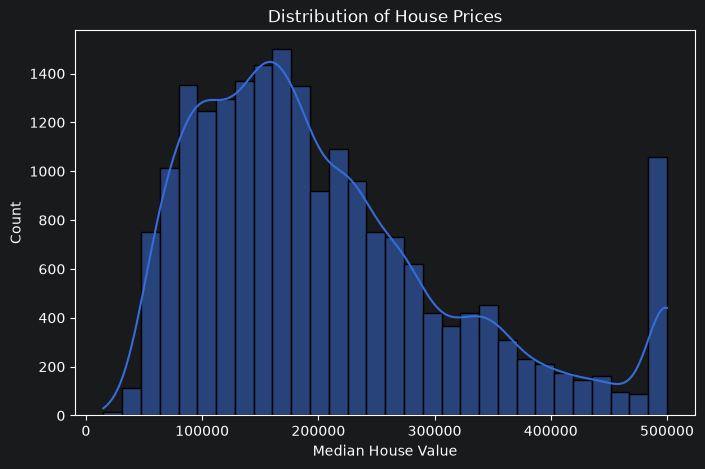

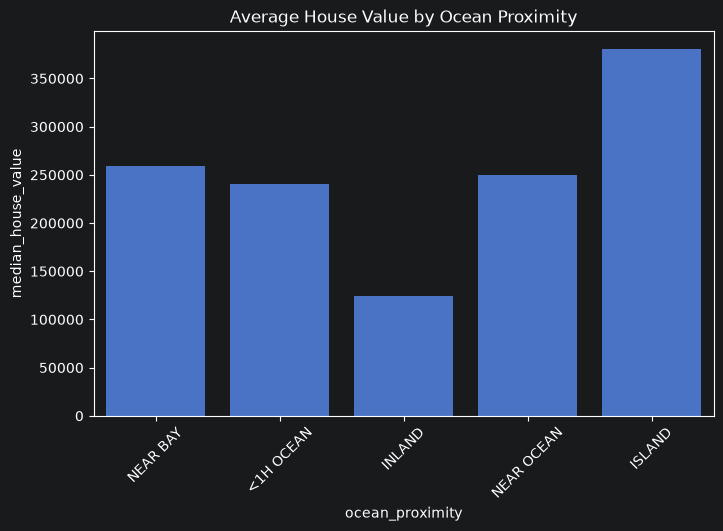

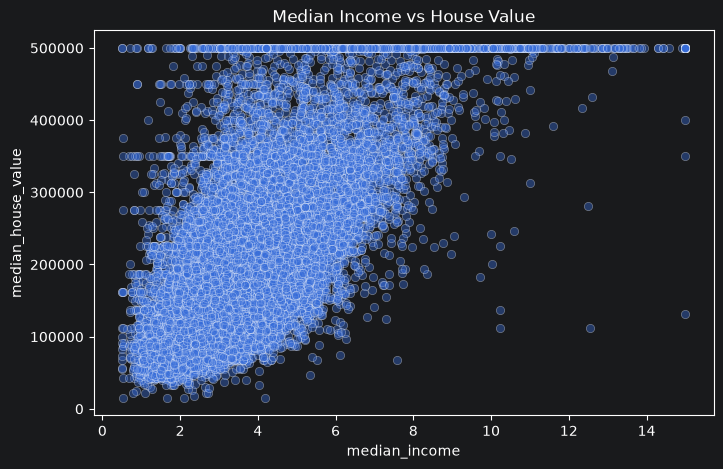

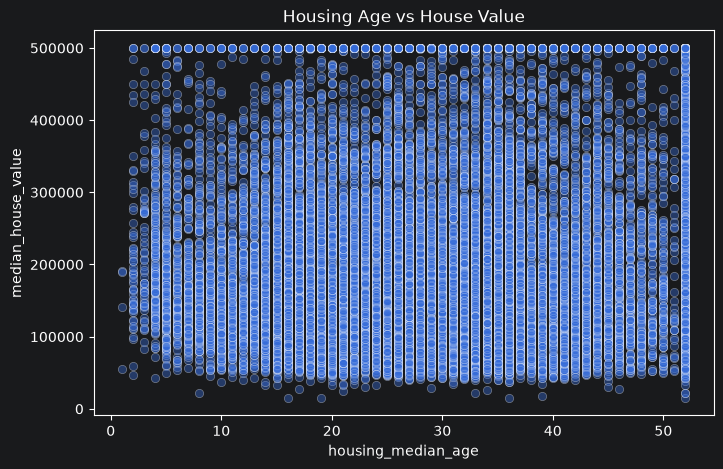

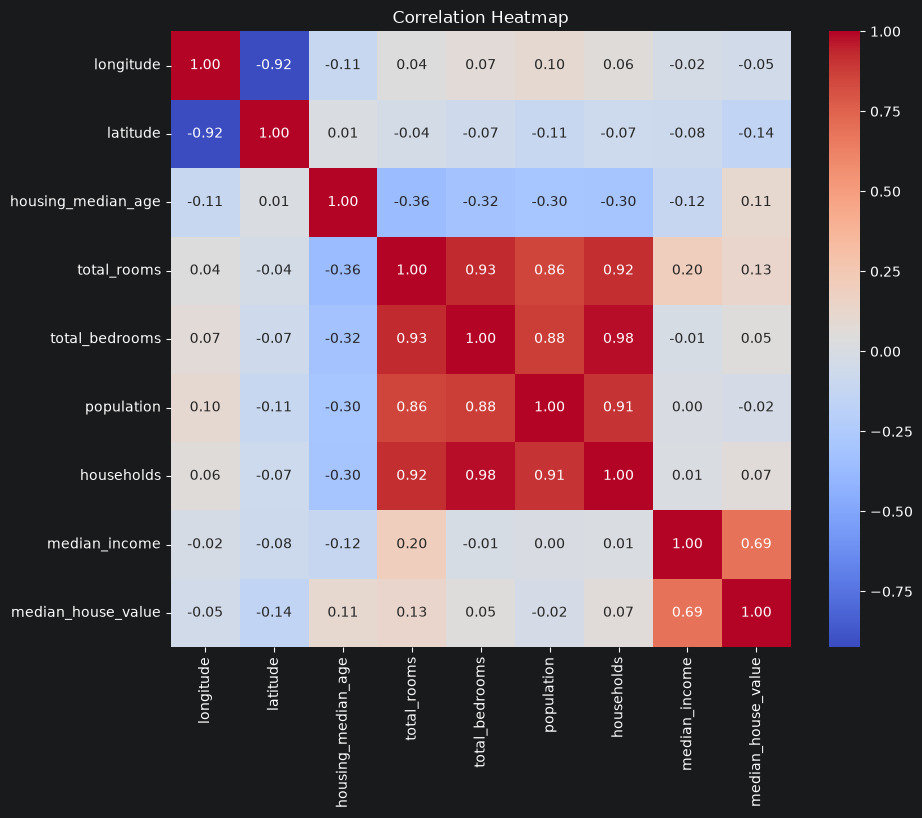

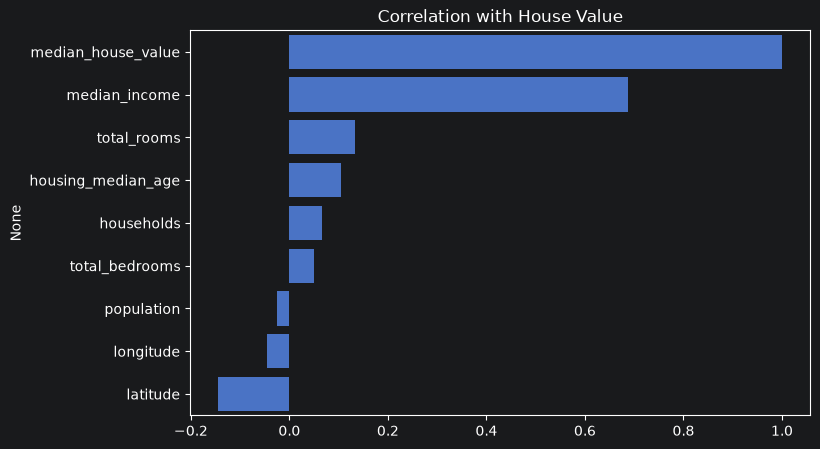

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


display(df.head())
display(df.describe())
display(df.isnull().sum().to_frame("Missing values"))

#Distribution of house prices

plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

#average house value by ocean proximity

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="ocean_proximity",
    y="median_house_value",
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Average House Value by Ocean Proximity")
plt.show()

#Median income vs house value

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value",
    alpha=0.4
)

plt.title("Median Income vs House Value")
plt.show()

# Housing age vs house value

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="housing_median_age",
    y="median_house_value",
    alpha=0.4
)

plt.title("Housing Age vs House Value")
plt.show()

#Correlation Heatmap

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
corr = numeric_df.corr()["median_house_value"].sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index)

plt.title("Correlation with House Value")
plt.show()

10 conclusions from the above analysis:
1. The distribution of house prices is right-skewed, indicating that there are a few very high-priced houses in the dataset.
2. There are 207 missing values in the "total_bedrooms" column, which may need to be addressed before modeling.
3. The average house value varies significantly based on ocean proximity, with houses closer to the ocean generally having higher values, while houses further inland tend to have lower values (in land).
4. There is a clear positive relationship between median income and median house value. As the median income increases, the median house value generally increases as well.
5. There is no clear linear relationship between housing median age and median house value. Houses with similar ages can have very different prices.
6. The strongest positive correlations are between:
- total rooms and total bedrooms (0.93)
- total rooms and population (0.86)
- total rooms and households (0.92)
- total bedrooms and population (0.88)
- total bedrooms and households (0.98)
- population and households (0.91)
- median income and median house value (0.69)
7. The strongest negative correlation is between longitude and latitude (-0.92).
8. Moderate negative correlations exist between median house value and both longitude (-0.05) and latitude (-0.14), suggesting that location may play a role in house pricing; house_median_age with: total_bedroom, total_rooms, households and population.
9. Moderate positive correlations exist between housing_median_age and median_house_value, total_rooms and median_income, total rooms and median_house_value.
10. Overall, the analysis suggests that factors such as ocean proximity, median income, and certain housing characteristics (like total rooms and total bedrooms) are important predictors of house value.

The most significant feature that correlates with house price is median_income.

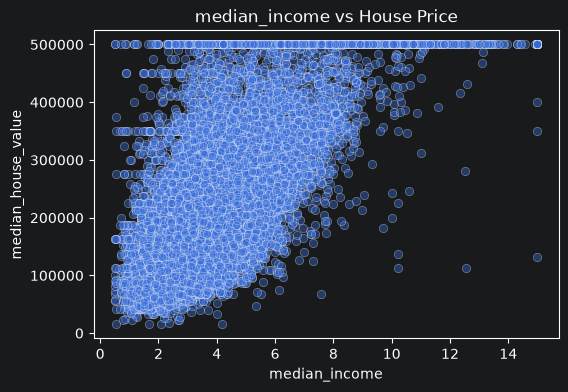

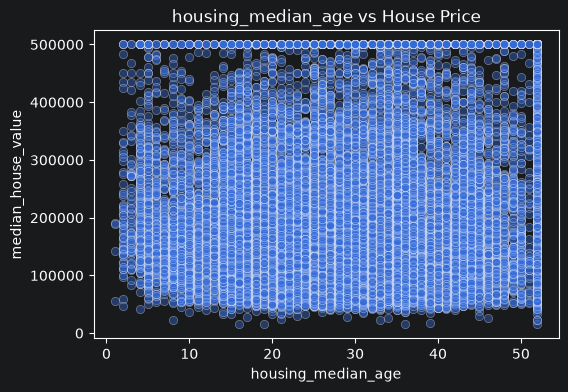

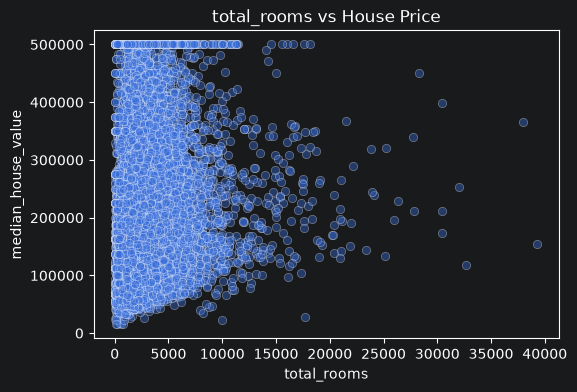

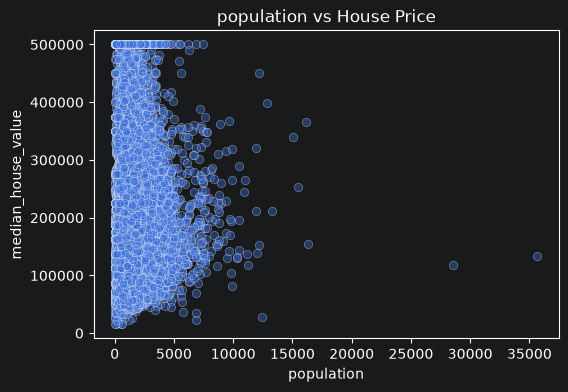

In [4]:
important_features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population"
]

for feature in important_features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=df[feature],
        y=df["median_house_value"],
        alpha=0.4
    )

    plt.title(f"{feature} vs House Price")

    plt.show()

scatter plots for every important feature.
the most significant feature correlated with house price is median_income, which is actually not surprising since income is a key factor in determining the affordability of housing.

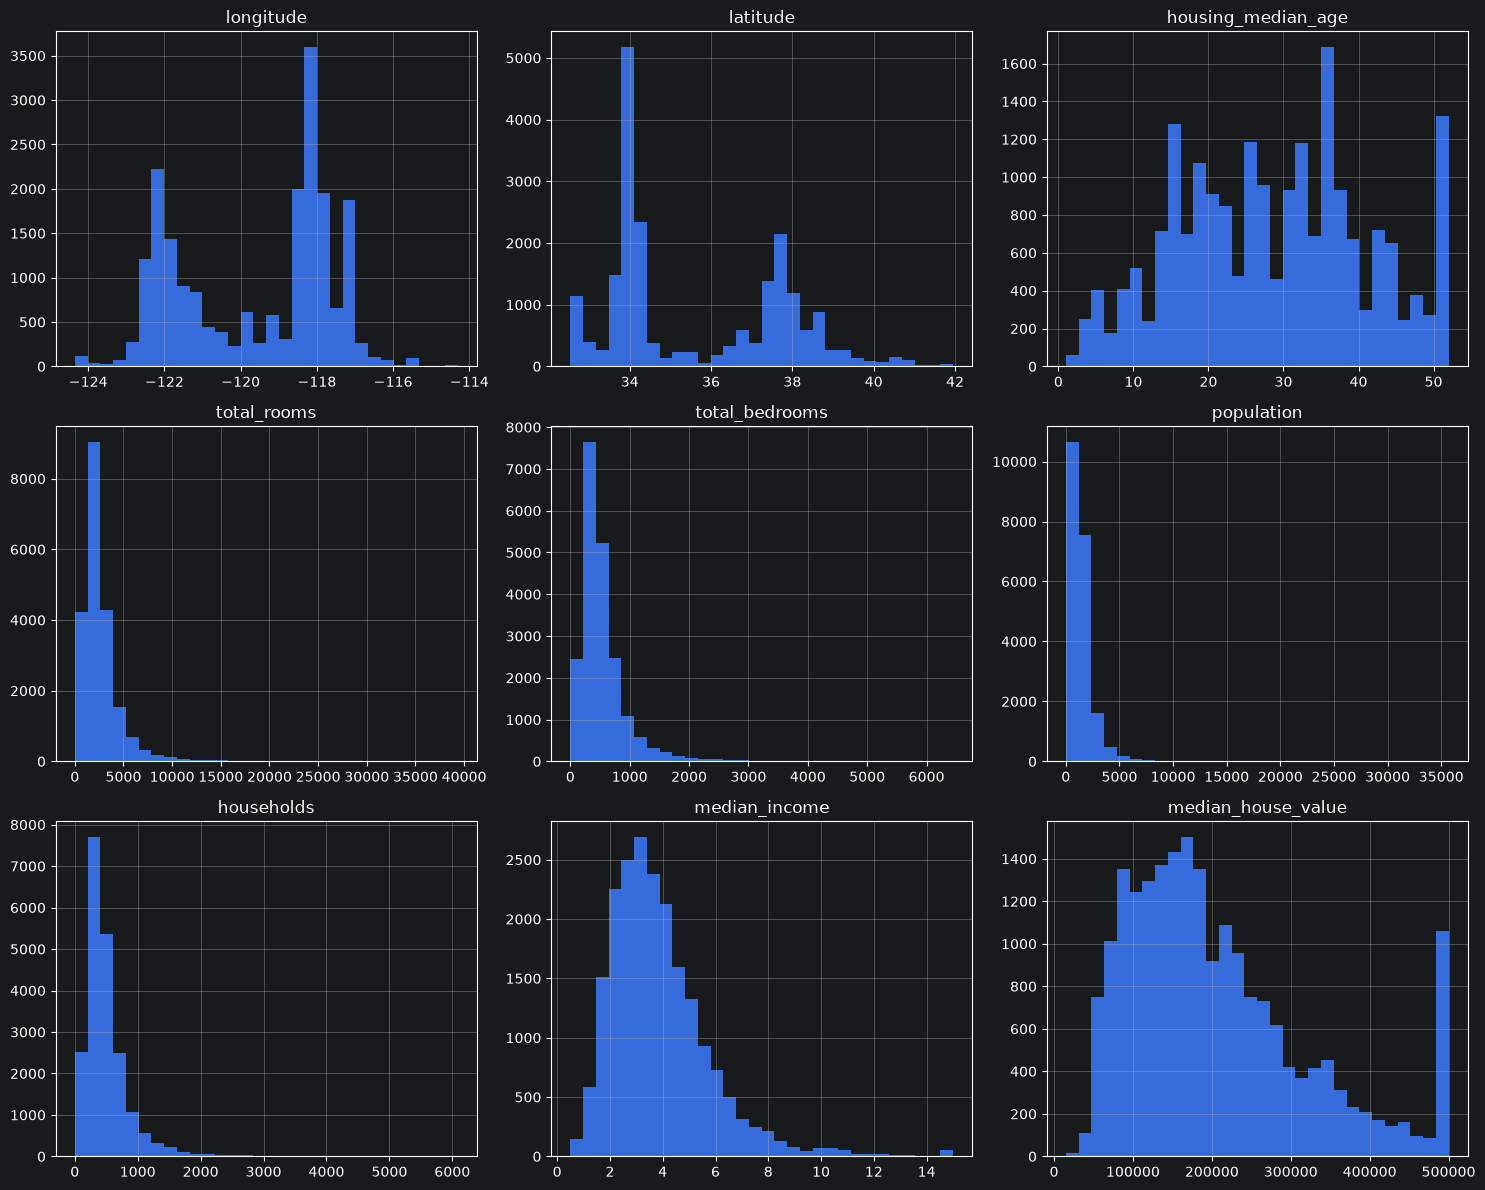

In [5]:
df.hist(
    figsize=(15,12),
    bins=30
)

plt.tight_layout()

plt.show()

ML Pipeline for car pricing
--------------------------------------------------------------------------

In [6]:
#we have 207 missing values so we have to treat them
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].mean()
)

In [7]:
#test if we have filled the missing value with the mean value of total bedrooms
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [8]:
#one hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)

In [9]:
#verificare pt ca am avut o eroare la ocean proximity inainte
df_encoded.head()
#aveam doar o coloana ocean proximtiy, nu era impartita pe categoriile din data set: near bay, near ocean etc

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [10]:
#we have to separate the features for target
X = df_encoded.drop("median_house_value", axis=1)

y = df_encoded["median_house_value"]

In [11]:
#train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
#verificare
print(X_train.shape)
print(X_test.shape)

(16512, 12)
(4128, 12)


In [13]:
#linear regression with evaluation (mae, rmse, r2)
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print(mae)
print(rmse)
print(r2)

50701.77903133012
70031.41991955669
0.6257351821159699


In [14]:
#random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [15]:
#gradient boosting
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [16]:
#cross validation
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

#Random Forest
rf = RandomForestRegressor(random_state=42)

#Cross Validation cu 5 fold-uri
scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("R2 pentru fiecare fold:", scores)
print("R2 mediu:", np.mean(scores))
print("Deviatia standard:", np.std(scores))

R2 pentru fiecare fold: [0.8223424  0.81464653 0.81978555 0.81935916 0.81343184]
R2 mediu: 0.8179130968714114
Deviatia standard: 0.003345683784820841


In [17]:
#grid search
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross Validation Score: 0.8186480196817103


In [18]:
#train final model with best found parameters
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [19]:
#evaluare on test data
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#predictiile
y_pred = best_rf.predict(X_test)

#calculam metricile de evaluare
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

MAE: 31518.80
RMSE: 48832.02
R2: 0.818


* mae - mean absolute error between predicted value and real value = 31519 dollars (approx)
* rmse - more sensitive to outliners = 48833 dollars (approx)
* r2 - the model has 81,8% accuracy, which is close to 1, so it is a pretty god model

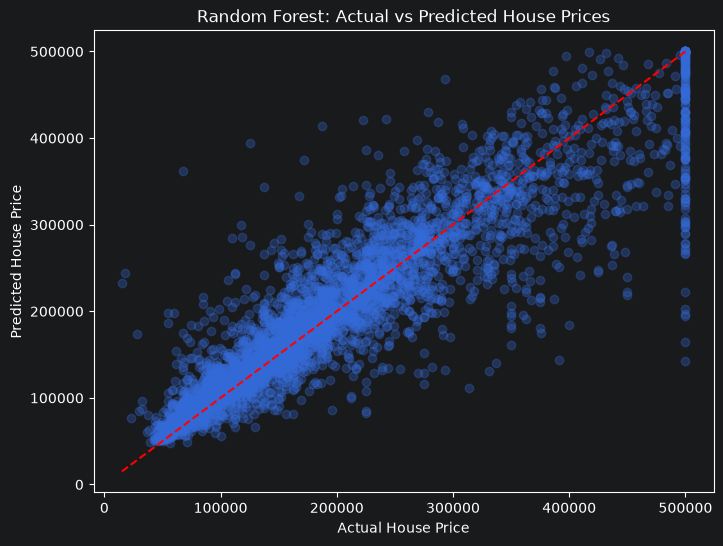

In [20]:
#actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Random Forest: Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

The closer the points lie to the red line, the more precise the model's predictions become.

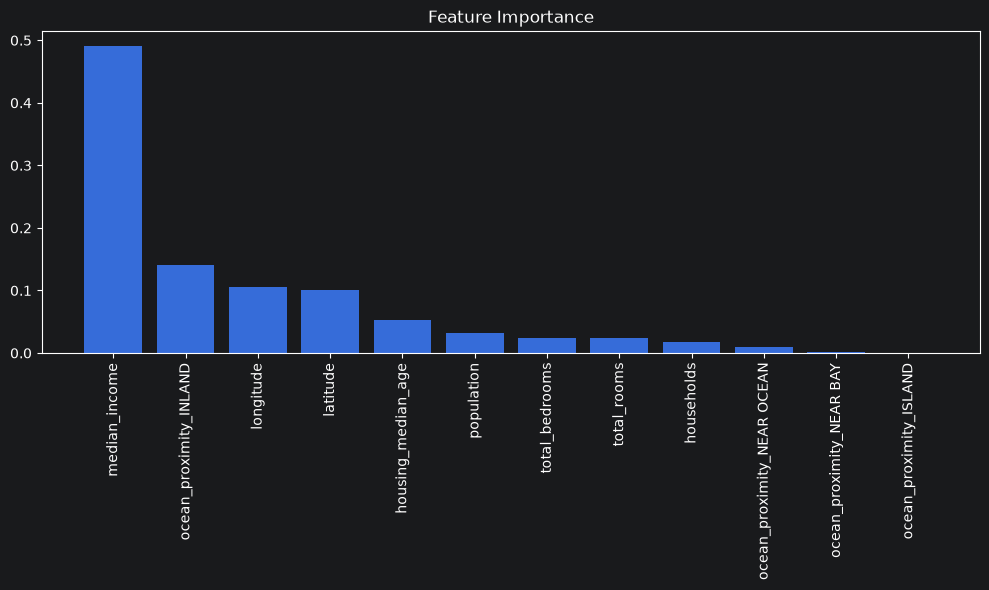

In [21]:
#feature importance
importances = best_rf.feature_importances_

indices = np.argsort(importances)[::-1]

features = X.columns

plt.figure(figsize=(10,6))

plt.title("Feature Importance")

plt.bar(
    range(len(importances)),
    importances[indices]
)

plt.xticks(
    range(len(importances)),
    features[indices],
    rotation=90
)

plt.tight_layout()

plt.show()

The most important feature in predicting house prices is median_income, it was actually derived from the above analysis.

Possible improvments:
- testing another algorithms (gradient boosting, xgboost etc)
- creating new features
- better treating of outliners
- additional adjustment of the parameters

In [22]:
#deployment: we save the model into a .pkl file for further predictions on new data, optional btw
import joblib

joblib.dump(best_rf, "house_price_model.pkl")

['house_price_model.pkl']